# UAV Fault Prediction Using Time-Series Machine Learning

## Abstract

This project focuses on **UAV fault detection and early fault prediction** using time-series flight telemetry data. The data includes control commands, measured states, velocity, IMU, and airspeed features collected from multiple UAV flights.

The data is chronologically processed, relevant features are selected, and features are standardized for model training. `binary_fault` represents the current fault state, while `fault_onset` identifies the transition from normal operation to a fault.

Three approaches will be evaluated: **XGBoost** as a baseline, **anomaly detection** for identifying abnormal pre-fault behavior, and **Liquid Neural Networks (LNN)** for learning temporal patterns. The final goal is to determine whether UAV faults can be **predicted before their onset**.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc,fbeta_score,precision_score, recall_score

In [40]:
df_train = pd.read_csv("../data/train_raw.csv")
df_test = pd.read_csv("../data/test_raw.csv")

# Dataset Size

In [41]:
df = df_train.copy()
df_test  = df_test.copy()
print("Original shape:", df.shape)
print("columans : ")
df.columns

Original shape: (132937, 24)
columans : 


Index(['bag', 'timestamp_ns', 'airspeed_cmd', 'airspeed_meas',
       'airspeed_error', 'roll_cmd', 'roll_meas', 'roll_error', 'pitch_cmd',
       'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'yaw_error',
       'vel_x', 'vel_y', 'vel_z', 'imu_x', 'imu_y', 'imu_z', 'engine_fault',
       'aileron_fault', 'elevator_fault', 'rudder_fault'],
      dtype='object')

In [42]:
df.dtypes

bag                object
timestamp_ns        int64
airspeed_cmd      float64
airspeed_meas     float64
airspeed_error    float64
roll_cmd          float64
roll_meas         float64
roll_error        float64
pitch_cmd         float64
pitch_meas        float64
pitch_error       float64
yaw_cmd           float64
yaw_meas          float64
yaw_error         float64
vel_x             float64
vel_y             float64
vel_z             float64
imu_x             float64
imu_y             float64
imu_z             float64
engine_fault        int64
aileron_fault       int64
elevator_fault      int64
rudder_fault        int64
dtype: object

# Correlaion of Data

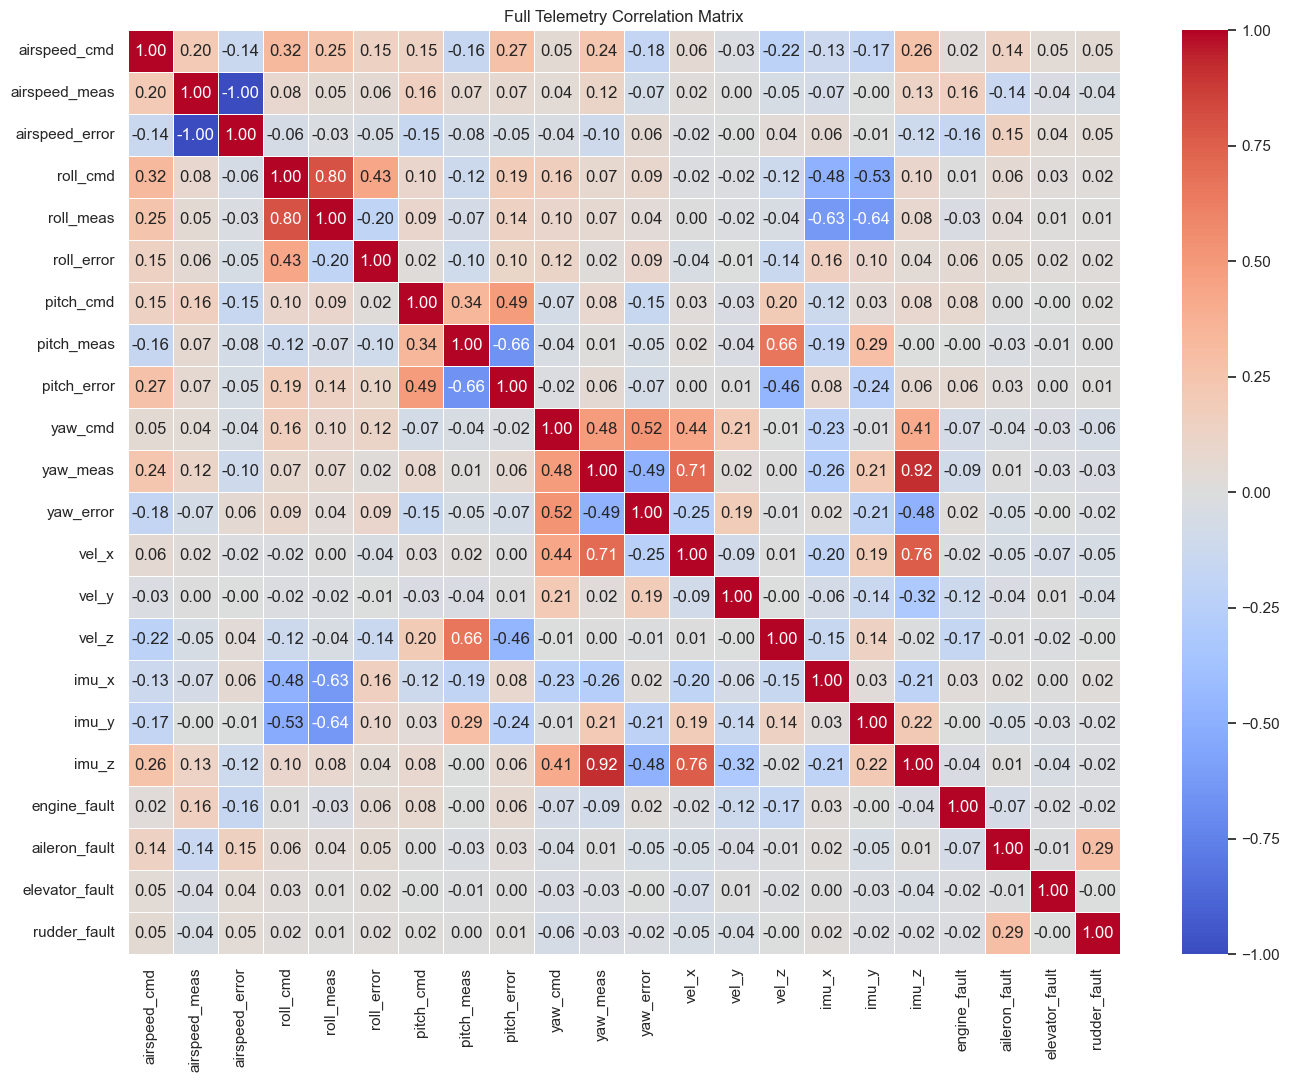

In [43]:
numerical_cols = df.drop(columns=['bag', 'timestamp_ns'], errors='ignore')
corr_matrix = numerical_cols.corr()

# 2. Plot the comprehensive heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Full Telemetry Correlation Matrix")
plt.show()

# Summary of Dataset

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp_ns,132937.0,1.536055e+18,2.790122e+15,1.531944e+18,1.532985e+18,1.536693e+18,1.538765e+18,1.539876e+18
airspeed_cmd,132937.0,1.562505e+01,4.834310e-01,1.500000e+01,1.500000e+01,1.600000e+01,1.600000e+01,1.600000e+01
airspeed_meas,132937.0,4.893964e+00,7.405477e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.448553e+01,2.648424e+01
airspeed_error,132937.0,1.073109e+01,7.322463e+00,-1.133438e+01,1.420175e+00,1.500000e+01,1.600000e+01,1.600000e+01
roll_cmd,132937.0,4.774754e+00,2.023759e+01,-4.500000e+01,-2.340000e+00,1.170000e+00,1.375000e+01,4.499000e+01
roll_meas,132937.0,6.370051e+00,1.865174e+01,-6.645238e+01,-1.124623e+00,2.366713e+00,1.384934e+01,7.128139e+01
roll_error,132937.0,-1.595298e+00,1.245943e+01,-1.062053e+02,-5.706806e+00,-8.780489e-01,3.903264e+00,9.828865e+01
pitch_cmd,132914.0,-6.528449e-01,5.751668e+00,-2.499000e+01,-3.690000e+00,-4.200000e-01,1.910000e+00,2.000000e+01
pitch_meas,132914.0,6.437144e-01,6.690156e+00,-5.688078e+01,-1.615566e+00,5.730504e-01,2.629524e+00,7.293653e+01
pitch_error,132914.0,-1.296559e+00,7.204381e+00,-9.304937e+01,-4.185391e+00,-1.114845e+00,1.695808e+00,5.941078e+01


## Critical Data Quality Issues Found in Raw Data
# Missing Values (NaNs):
- timestamp_ns & airspeed_*:132937 rows (Complete).
- pitch_*: 132937  rows (23 missing values).
- yaw_*: 132937  rows (21 missing values).
- vel_x, vel_y, vel_z: 172,480 rows (8,318 missing values missing!).
# Raw yaw_error Discontinuity:
- Min: -358.79, Max: +358.99.
- Observation: Raw yaw_error spans nearly $\pm 360^\circ$ due to standard $\pm 180^\circ$ compass wrap-around leaps. Angle wrapping to $[-180^\circ, +180^\circ]$ is mandatory.
# Feature Scaling
-  UAV features have very different numerical ranges which can be affect in modeling .



# Sort chronologically(Time series)

In [45]:
df = df.sort_values(
    by=["bag", "timestamp_ns"]
).reset_index(drop=True)

df_test = df_test.sort_values(
    by=["bag", "timestamp_ns"]
).reset_index(drop=True)

print(df[["bag", "timestamp_ns"]].head())


                               bag         timestamp_ns
0  carbonZ_2018-07-18-15-53-31.bag  1531943612183833069
1  carbonZ_2018-07-18-15-53-31.bag  1531943612184097830
2  carbonZ_2018-07-18-15-53-31.bag  1531943612184574457
3  carbonZ_2018-07-18-15-53-31.bag  1531943612214173518
4  carbonZ_2018-07-18-15-53-31.bag  1531943612255185463


# Identify individual flights
It allows me to keep different flights separate.

In [46]:
gap_ns_threshold = 1000 * 1e9  # 1000 seconds

def add_flight_id(data, gap_ns_threshold):
    data = data.copy()
    data["time_gap_ns"] = (
        data.groupby("bag", sort=False)["timestamp_ns"]
            .diff()
    )
    bag_changed = data["bag"] != data["bag"].shift(1)
    large_gap = data["time_gap_ns"] > gap_ns_threshold
    data["flight_id"] = (bag_changed | large_gap).cumsum() - 1
    data.drop(columns=["time_gap_ns"], inplace=True)
    return data

df = add_flight_id(df, gap_ns_threshold)
df_test = add_flight_id(df_test, gap_ns_threshold)

print("Number of train flights:", df["flight_id"].nunique())
print(df["flight_id"].value_counts().sort_index())

print("\nNumber of test flights:", df_test["flight_id"].nunique())
print(df_test["flight_id"].value_counts().sort_index())


Number of train flights: 30
flight_id
0      7760
1      2474
2      4029
3      2894
4      2798
5     11076
6       977
7      2771
8      2878
9      3603
10     2385
11     3603
12     1320
13      966
14     3699
15     6481
16     5185
17     3293
18    10639
19     5721
20     6283
21    14494
22     6499
23     4665
24     1866
25     2591
26     2667
27     5190
28     2622
29     1508
Name: count, dtype: int64

Number of test flights: 6
flight_id
0     4306
1     6115
2    24329
3     7842
4     2749
5     2534
Name: count, dtype: int64


# Create flight-relative time
Absolute ROS timestamps aren't useful for comparing flights. That's why I change relative time for 
- identifying fault onset
- creating future targets
- creating time windows
- plotting behavior before faults

In [47]:
df["flight_time_sec"] = (
    df.groupby("flight_id", sort=False)["timestamp_ns"]
      .transform(lambda x: (x - x.min()) / 1e9)
)

df_test["flight_time_sec"] = (
    df_test.groupby("flight_id", sort=False)["timestamp_ns"]
      .transform(lambda x: (x - x.min()) / 1e9)
)

df[["flight_id", "flight_time_sec"]].head(10)


,flight_id,flight_time_sec
0,0,0.000000
1,0,0.000265
2,0,0.000741
3,0,0.030340
4,0,0.071352
5,0,0.159289
6,0,0.193384
7,0,0.241772
8,0,0.275060
9,0,0.342245


# Fill missing value
Used Forward fill and backward fill because data is timeseries.

In [48]:
fill_cols = [c for c in ['vel_x', 'vel_y', 'vel_z', 'pitch_cmd', 'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'yaw_error'] if c in df.columns]
df[fill_cols] = df.groupby('flight_id', sort=False)[fill_cols].ffill().bfill()

# test set - same columns, filled within its own flight_id groups
fill_cols_test = [c for c in fill_cols if c in df_test.columns]
df_test[fill_cols_test] = df_test.groupby('flight_id', sort=False)[fill_cols_test].ffill().bfill()


# Correct the yaw error
Yaw is circular.
For example:

Command = 179°
Measured = -179°

The ordinary difference is: 358°
but physically the UAV is only about 2° away.

The wrapped version correctly represents the circular difference.

In [49]:
df["yaw_error_clean"] = (
    (df["yaw_error"] + 180) % 360
) - 180

df_test["yaw_error_clean"] = (
    (df_test["yaw_error"] + 180) % 360
) - 180


# Added new Feature called Ground speed 
Instead of looking at three velocity components separately, this gives us the overall magnitude of the UAV's velocity.
Ground speed was derived from the three-dimensional velocity components to represent the overall magnitude of UAV motion. While vel_x, vel_y, and vel_z capture directional movement, ground_speed provides a compact measure of overall flight dynamics. This feature may help identify changes in UAV motion associated with developing faults.

In [50]:
df["ground_speed"] = np.sqrt(
    df["vel_x"]**2 +
    df["vel_y"]**2 +
    df["vel_z"]**2
)

df_test["ground_speed"] = np.sqrt(
    df_test["vel_x"]**2 +
    df_test["vel_y"]**2 +
    df_test["vel_z"]**2
)

df["ground_speed"].describe()


count    132937.000000
mean         15.215076
std           7.197670
min           0.010152
25%          13.928278
50%          16.871769
75%          19.541066
max          31.503337
Name: ground_speed, dtype: float64

# Class Imbalance 
Class are imbalance so combine all fault type into binary type . It will be also important for finding transition before fault happen for another approach.

In [51]:
fault_cols = ['engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault']
present_faults = [c for c in fault_cols if c in df.columns]
if present_faults:
    df['binary_fault'] = (df[present_faults] > 0).any(axis=1).astype(int)
    
present_faults = [c for c in fault_cols if c in df_test.columns]
if present_faults:
    df_test['binary_fault'] = (df_test[present_faults] > 0).any(axis=1).astype(int)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30292\4159042800.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


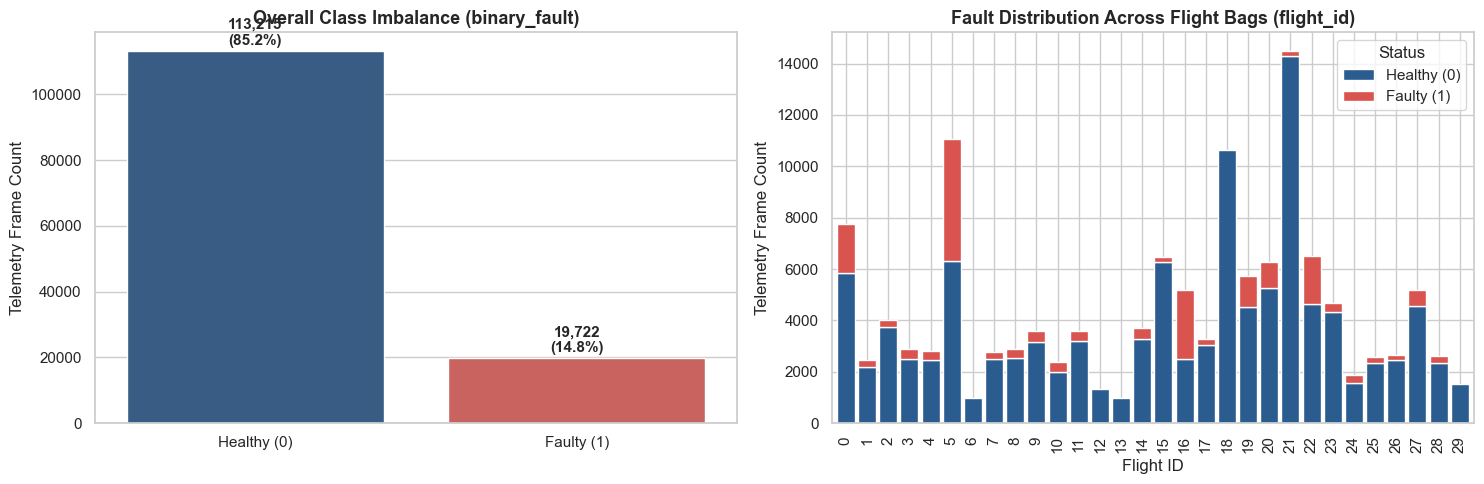

In [52]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Global Class Imbalance Bar Plot
fault_counts = df['binary_fault'].value_counts().sort_index()
percentages = df['binary_fault'].value_counts(normalize=True).sort_index() * 100

bars = sns.barplot(
    x=['Healthy (0)', 'Faulty (1)'], 
    y=fault_counts.values, 
    ax=axes[0], 
    palette=['#2b5c8f', '#d9534f']
)
axes[0].set_title('Overall Class Imbalance (binary_fault)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Telemetry Frame Count')

# Label bar counts and percentages
for i, count in enumerate(fault_counts.values):
    pct = percentages.values[i]
    axes[0].text(i, count + 1800, f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

# 2. Per-Flight Fault Distribution (Stacked Bar)
flight_faults = df.groupby(['flight_id', 'binary_fault']).size().unstack(fill_value=0)
flight_faults.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[1], 
    color=['#2b5c8f', '#d9534f'], 
    width=0.85
)
axes[1].set_title('Fault Distribution Across Flight Bags (flight_id)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Flight ID')
axes[1].set_ylabel('Telemetry Frame Count')
axes[1].legend(['Healthy (0)', 'Faulty (1)'], title='Status', frameon=True)
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# Remove columns that are not need

In [53]:
cols_to_drop = [
    "timestamp_ns",
    "bag",
    "yaw_error",
    "engine_fault",
    "aileron_fault",
    "elevator_fault",
    "rudder_fault"
]

df = df.drop(
    columns=[
        c for c in cols_to_drop
        if c in df.columns
    ],
    errors="ignore"
)

print("Current train shape:", df.shape)

df_test = df_test.drop(
    columns=[
        c for c in cols_to_drop
        if c in df_test.columns
    ],
    errors="ignore"
)
print("Current test shape : ",df_test.shape)

Current train shape: (132937, 22)
Current test shape :  (47875, 22)


# Create Fault_onset
binary_fault describes the current fault state:

0 = normal ,
1 = currently faulty

However, for predictive modeling, we need to identify the exact moment when the system changes from normal to faulty.



By checking the start and end of each fault interval

- when a fault begins,
- how long the fault remains active,
- whether a flight contains multiple fault periods,
- whether any fault starts at the beginning of the recording.

This is important because goal is not simply to detect whether the UAV is currently faulty. I want to understand the behavior before a fault occurs.

In [54]:
# Calculate fault intervals
intervals = []

for flight_id, group in df.groupby("flight_id"):
    
    group = group.sort_values("flight_time_sec")
    
    fault_start = None
    
    for _, row in group.iterrows():
        
        if row["binary_fault"] == 1 and fault_start is None:
            fault_start = row["flight_time_sec"]
            
        elif row["binary_fault"] == 0 and fault_start is not None:
            fault_end = row["flight_time_sec"]
            
            intervals.append({
                "flight_id": flight_id,
                "fault_start": fault_start,
                "fault_end": fault_end,
                "duration_sec": fault_end - fault_start
            })
            
            fault_start = None

intervals_df = pd.DataFrame(intervals)

intervals_df

,flight_id,fault_start,fault_end,duration_sec
0,0,314.986822,356.308923,41.322102
1,5,0.000000,474.809016,474.809016
2,5,962.539142,1051.033837,88.494695
3,5,1181.753807,1237.156000,55.402193
4,14,115.097247,178.789042,63.691795
5,15,400.193820,442.886674,42.692855
6,16,116.333558,310.004298,193.670740
7,17,154.043161,195.097552,41.054391
8,19,188.193003,242.035303,53.842300
9,20,538.130770,586.950424,48.819654


- Using binary_fault alone would mainly teach a model to recognize an already-existing fault.

- Using fault_onset allows us to investigate whether the sensor patterns before the onset contain information that can be used for early fault prediction.

In [55]:
def compute_fault_onset(data):
    data = data.sort_values(
        ["flight_id", "flight_time_sec"]
    ).reset_index(drop=True)

    data["fault_onset"] = (
        (data["binary_fault"] == 1) &
        (
            data.groupby("flight_id")["binary_fault"]
                .shift(1)
                .fillna(0)
                .eq(0)
        )
    ).astype(int)
    return data

df = compute_fault_onset(df)
df_test = compute_fault_onset(df_test)

print("Train fault_onset counts:")
print(df["fault_onset"].value_counts())
print("\nTest fault_onset counts:")
print(df_test["fault_onset"].value_counts())


Train fault_onset counts:
fault_onset
0    132904
1        33
Name: count, dtype: int64

Test fault_onset counts:
fault_onset
0    47869
1        6
Name: count, dtype: int64


# Predictive Target: Fault within next 5 seconds

`binary_fault` tells us the fault is happening **right now** — a model trained on it is only detecting an existing fault, not predicting one.

To make this genuinely predictive, we build `fault_within_5s`: for every frame (within a single flight), look forward `horizon_sec = 5.0` seconds and check whether a `fault_onset` occurs in that window.

We also **drop frames where `binary_fault == 1`** from the predictive dataset. Those frames are already mid-fault, so keeping them would let the model just detect the ongoing fault instead of learning the pre-fault signature.


In [56]:
HORIZON_SEC = 5.0

def add_future_fault_label(data, horizon_sec=HORIZON_SEC):
    data = data.sort_values(
        ["flight_id", "flight_time_sec"]
    ).reset_index(drop=True)

    labels = np.zeros(len(data), dtype=int)

    for flight_id, group in data.groupby("flight_id"):
        idx = group.index.values
        times = group["flight_time_sec"].values
        onset_times = np.sort(times[group["fault_onset"].values == 1])

        if len(onset_times) == 0:
            continue

        # for each time t: does an onset occur in (t, t + horizon_sec] ?
        lo = np.searchsorted(onset_times, times, side="right")
        hi = np.searchsorted(onset_times, times + horizon_sec, side="right")
        labels[idx] = (hi > lo).astype(int)

    data["fault_within_5s"] = labels
    return data

df = add_future_fault_label(df)
df_test = add_future_fault_label(df_test)

print("Train fault_within_5s counts (all frames):")
print(df["fault_within_5s"].value_counts())
print("\nTest fault_within_5s counts (all frames):")
print(df_test["fault_within_5s"].value_counts())

# Predictive subsets: only frames that are NOT already mid-fault
df_pred = df[df["binary_fault"] == 0].copy()
df_test_pred = df_test[df_test["binary_fault"] == 0].copy()

print("\nTrain predictive-subset fault_within_5s counts (binary_fault==0 only):")
print(df_pred["fault_within_5s"].value_counts())
print("\nTest predictive-subset fault_within_5s counts (binary_fault==0 only):")
print(df_test_pred["fault_within_5s"].value_counts())


Train fault_within_5s counts (all frames):
fault_within_5s
0    129905
1      3032
Name: count, dtype: int64

Test fault_within_5s counts (all frames):
fault_within_5s
0    47405
1      470
Name: count, dtype: int64

Train predictive-subset fault_within_5s counts (binary_fault==0 only):
fault_within_5s
0    110183
1      3032
Name: count, dtype: int64

Test predictive-subset fault_within_5s counts (binary_fault==0 only):
fault_within_5s
0    40665
1      470
Name: count, dtype: int64


In [57]:
flights_to_check = intervals_df['flight_id'].unique()[:3]  # first 3 faulty flights

for flight_id in flights_to_check:
    flight_data = df[df['flight_id'] == flight_id].sort_values('flight_time_sec')
    onset_row = flight_data[flight_data['fault_onset'] == 1]

    if len(onset_row) == 0:
        continue

    onset_time = onset_row['flight_time_sec'].iloc[0]

    # window: 8 seconds before onset to 3 seconds after
    window = flight_data[
        (flight_data['flight_time_sec'] >= onset_time - 8) &
        (flight_data['flight_time_sec'] <= onset_time + 3)
    ][['flight_time_sec', 'binary_fault', 'fault_onset', 'fault_within_5s']]

    print(f"\n{'='*60}")
    print(f"Flight {flight_id} — fault onset at {onset_time:.2f}s")
    print(f"{'='*60}")
    print(window.to_string(index=False))


Flight 0 — fault onset at 314.99s
 flight_time_sec  binary_fault  fault_onset  fault_within_5s
      307.018810             0            0                0
      307.062403             0            0                0
      307.091348             0            0                0
      307.183079             0            0                0
      307.206007             0            0                0
      307.253568             0            0                0
      307.298248             0            0                0
      307.385064             0            0                0
      307.392964             0            0                0
      307.475702             0            0                0
      307.532385             0            0                0
      307.554848             0            0                0
      307.591280             0            0                0
      307.627361             0            0                0
      307.723469             0            0       

In [58]:
print("Shape :",df.shape)
df.describe().T

Shape : (132937, 24)


,count,mean,std,min,25%,50%,75%,max
airspeed_cmd,132937.0,15.625053,0.483431,15.000000,15.000000,16.000000,16.000000,16.000000
airspeed_meas,132937.0,4.893964,7.405477,0.000000,0.000000,0.000000,14.485530,26.484240
airspeed_error,132937.0,10.731088,7.322463,-11.334381,1.420175,15.000000,16.000000,16.000000
roll_cmd,132937.0,4.774754,20.237594,-45.000000,-2.340000,1.170000,13.750000,44.989998
roll_meas,132937.0,6.370051,18.651736,-66.452385,-1.124623,2.366713,13.849339,71.281387
roll_error,132937.0,-1.595298,12.459434,-106.205280,-5.706806,-0.878049,3.903264,98.288647
pitch_cmd,132937.0,-0.652871,5.751217,-24.990000,-3.690000,-0.420000,1.910000,20.000000
pitch_meas,132937.0,0.643736,6.689591,-56.880775,-1.612970,0.573268,2.628115,72.936531
pitch_error,132937.0,-1.296607,7.203785,-93.049374,-4.185391,-1.114845,1.695190,59.410775
yaw_cmd,132937.0,-13.831289,99.545602,-179.000000,-88.000000,0.000000,89.000000,180.000000


# Normalization and Outlier 
I do  not automatically remove outliers because an extreme value may be the actual signal of a developing fault, not a bad data point.

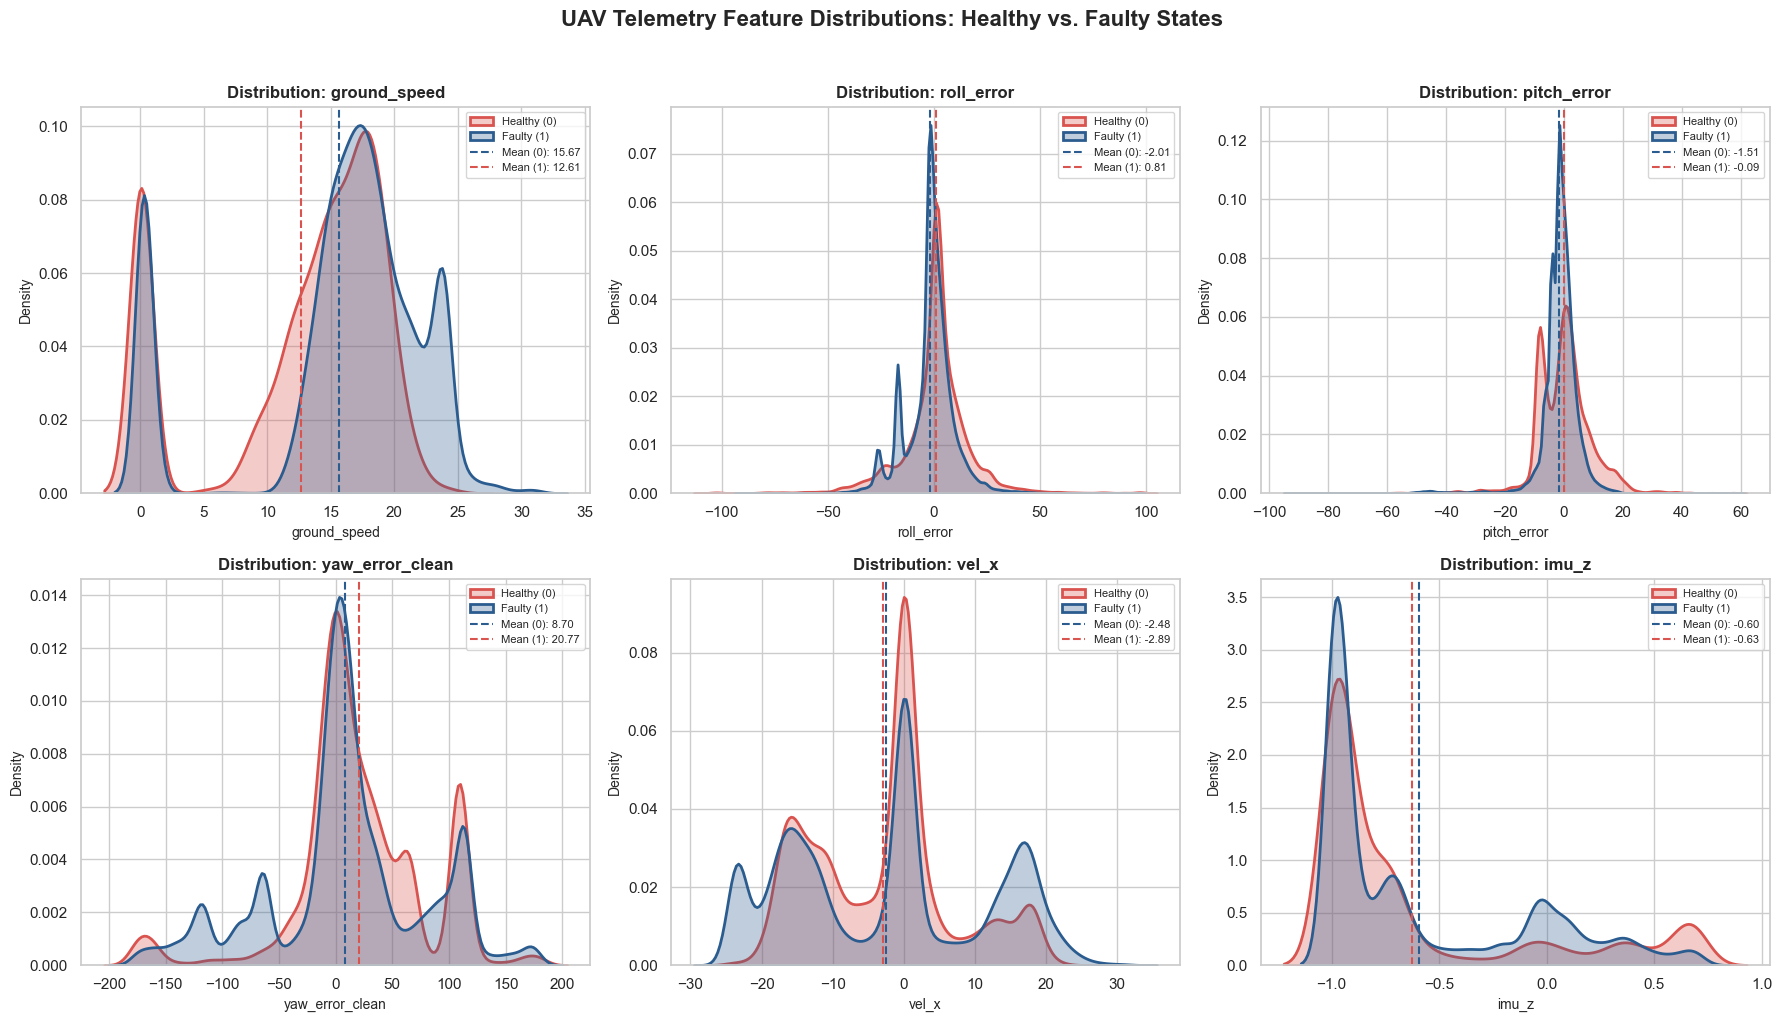

In [59]:
# Set visual style
sns.set_theme(style="whitegrid")

# Select core features to inspect distribution shifts
plot_features = [
    'ground_speed', 
    'roll_error', 
    'pitch_error', 
    'yaw_error_clean',
    'vel_x', 
    'imu_z'
]

# Create subplots grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    # Kernel Density Estimation (KDE) plot grouped by binary_fault
    sns.kdeplot(
        data=df,
        x=feature,
        hue='binary_fault',
        common_norm=False,
        palette={0: '#2b5c8f', 1: '#d9534f'},
        fill=True,
        alpha=0.3,
        linewidth=2,
        ax=ax
    )
    
    # Calculate means per class for reference lines
    mean_0 = df[df['binary_fault'] == 0][feature].mean()
    mean_1 = df[df['binary_fault'] == 1][feature].mean()
    
    ax.axvline(mean_0, color='#2b5c8f', linestyle='--', linewidth=1.5, label=f'Healthy Mean: {mean_0:.2f}')
    ax.axvline(mean_1, color='#d9534f', linestyle='--', linewidth=1.5, label=f'Faulty Mean: {mean_1:.2f}')
    
    ax.set_title(f'Distribution: {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(['Healthy (0)', 'Faulty (1)', f'Mean (0): {mean_0:.2f}', f'Mean (1): {mean_1:.2f}'], fontsize=8)

plt.suptitle('UAV Telemetry Feature Distributions: Healthy vs. Faulty States', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Feature scaling 
Feature scaling is applied because the sensor and control variables have very different numerical ranges.
I used StandScaler as basedline

In [60]:
features = [
    'airspeed_cmd', 'airspeed_meas', 'airspeed_error',
    'roll_cmd', 'roll_meas', 'roll_error',
    'pitch_cmd', 'pitch_meas', 'pitch_error',
    'yaw_cmd', 'yaw_meas', 'yaw_error_clean',
    'vel_x', 'vel_y', 'vel_z',
    'imu_x', 'imu_y', 'imu_z',
    'ground_speed'
]

# Split flights (not rows) into train/val to avoid leaking a flight across both sets.
# Use the predictive subset (binary_fault == 0 frames only) for this task.
unique_flights = df_pred['flight_id'].unique()
np.random.seed(42)
val_flights = np.random.choice(unique_flights, size=int(len(unique_flights) * 0.2), replace=False)

train_mask = ~df_pred['flight_id'].isin(val_flights)
val_mask = df_pred['flight_id'].isin(val_flights)

# 3. Raw Feature Matrices
X_train_raw = df_pred.loc[train_mask, features].copy()
X_val_raw = df_pred.loc[val_mask, features].copy()
X_test_raw = df_test_pred[features].copy()

# 4. Leak-Free Scaling (Fit strictly on Train, Transform val AND test)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 5. Create DataFrame versions (Preserves column names and original indices)
df_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train_raw.index
)

df_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=features,
    index=X_val_raw.index
)

df_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test_raw.index
)

# 6. Target and Metadata Alignments — predictive target: fault within next 5s
y_train = df_pred.loc[train_mask, 'fault_within_5s'].copy()
y_val = df_pred.loc[val_mask, 'fault_within_5s'].copy()
y_test = df_test_pred['fault_within_5s'].copy()

flight_id_train = df_pred.loc[train_mask, 'flight_id'].copy()
flight_id_val = df_pred.loc[val_mask, 'flight_id'].copy()
flight_id_test = df_test_pred['flight_id'].copy()

# 7. Verification Summary
print(f"Train Scaled Shape: {df_train_scaled.shape} | Targets: {y_train.shape}")
print(f"Val Scaled Shape:   {df_val_scaled.shape}   | Targets: {y_val.shape}")
print(f"Test Scaled Shape:  {df_test_scaled.shape}  | Targets: {y_test.shape}")
print(f"Train Flights ({len(np.unique(flight_id_train))}): {np.unique(flight_id_train)}")
print(f"Val Flights   ({len(np.unique(flight_id_val))}): {np.unique(flight_id_val)}")
print(f"Test Flights  ({len(np.unique(flight_id_test))}): {np.unique(flight_id_test)}")
print(f"\nTrain positive rate: {y_train.mean():.4f}")
print(f"Val positive rate:   {y_val.mean():.4f}")
print(f"Test positive rate:  {y_test.mean():.4f}")


Train Scaled Shape: (89325, 19) | Targets: (89325,)
Val Scaled Shape:   (23890, 19)   | Targets: (23890,)
Test Scaled Shape:  (41135, 19)  | Targets: (41135,)
Train Flights (24): [ 0  1  2  3  4  5  6  7 10 11 12 13 14 16 18 19 20 21 22 24 25 26 28 29]
Val Flights   (6): [ 8  9 15 17 23 27]
Test Flights  (6): [0 1 2 3 4 5]

Train positive rate: 0.0266
Val positive rate:   0.0276
Test positive rate:  0.0114


In [61]:
df_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
airspeed_cmd,89325.0,-1.512006e-15,1.000006,-1.165579,-1.165579,0.859860,0.859860,0.859860
airspeed_meas,89325.0,-1.832735e-16,1.000006,-0.663364,-0.663364,-0.663364,1.320767,2.808991
airspeed_error,89325.0,8.145489e-17,1.000006,-2.920210,-1.294256,0.599287,0.732933,0.732933
roll_cmd,89325.0,-5.345477e-17,1.000006,-2.433872,-0.398192,-0.172335,0.402707,2.023327
roll_meas,89325.0,-2.227282e-17,1.000006,-3.854971,-0.413677,-0.226422,0.345129,3.521856
roll_error,89325.0,-3.563651e-17,1.000006,-7.318846,-0.386222,0.077845,0.497806,8.539593
pitch_cmd,89325.0,1.400006e-17,1.000006,-4.674195,-0.429724,0.125322,0.486391,3.966473
pitch_meas,89325.0,2.290919e-17,1.000006,-8.231758,-0.301324,-0.052849,0.213514,9.962879
pitch_error,89325.0,-2.545465e-17,1.000006,-13.328695,-0.335794,0.036149,0.418622,8.881773
yaw_cmd,89325.0,-4.581837e-17,1.000006,-1.633713,-0.721590,0.180399,1.041850,2.004647


In [62]:
# Train Splits (predictive target)
y_train_target    = df_pred.loc[train_mask, "fault_within_5s"].copy()
flight_id_train   = df_pred.loc[train_mask, "flight_id"].copy()
flight_time_train = df_pred.loc[train_mask, "flight_time_sec"].copy()

# Validation Splits
y_val_target    = df_pred.loc[val_mask, "fault_within_5s"].copy()
flight_id_val   = df_pred.loc[val_mask, "flight_id"].copy()
flight_time_val = df_pred.loc[val_mask, "flight_time_sec"].copy()


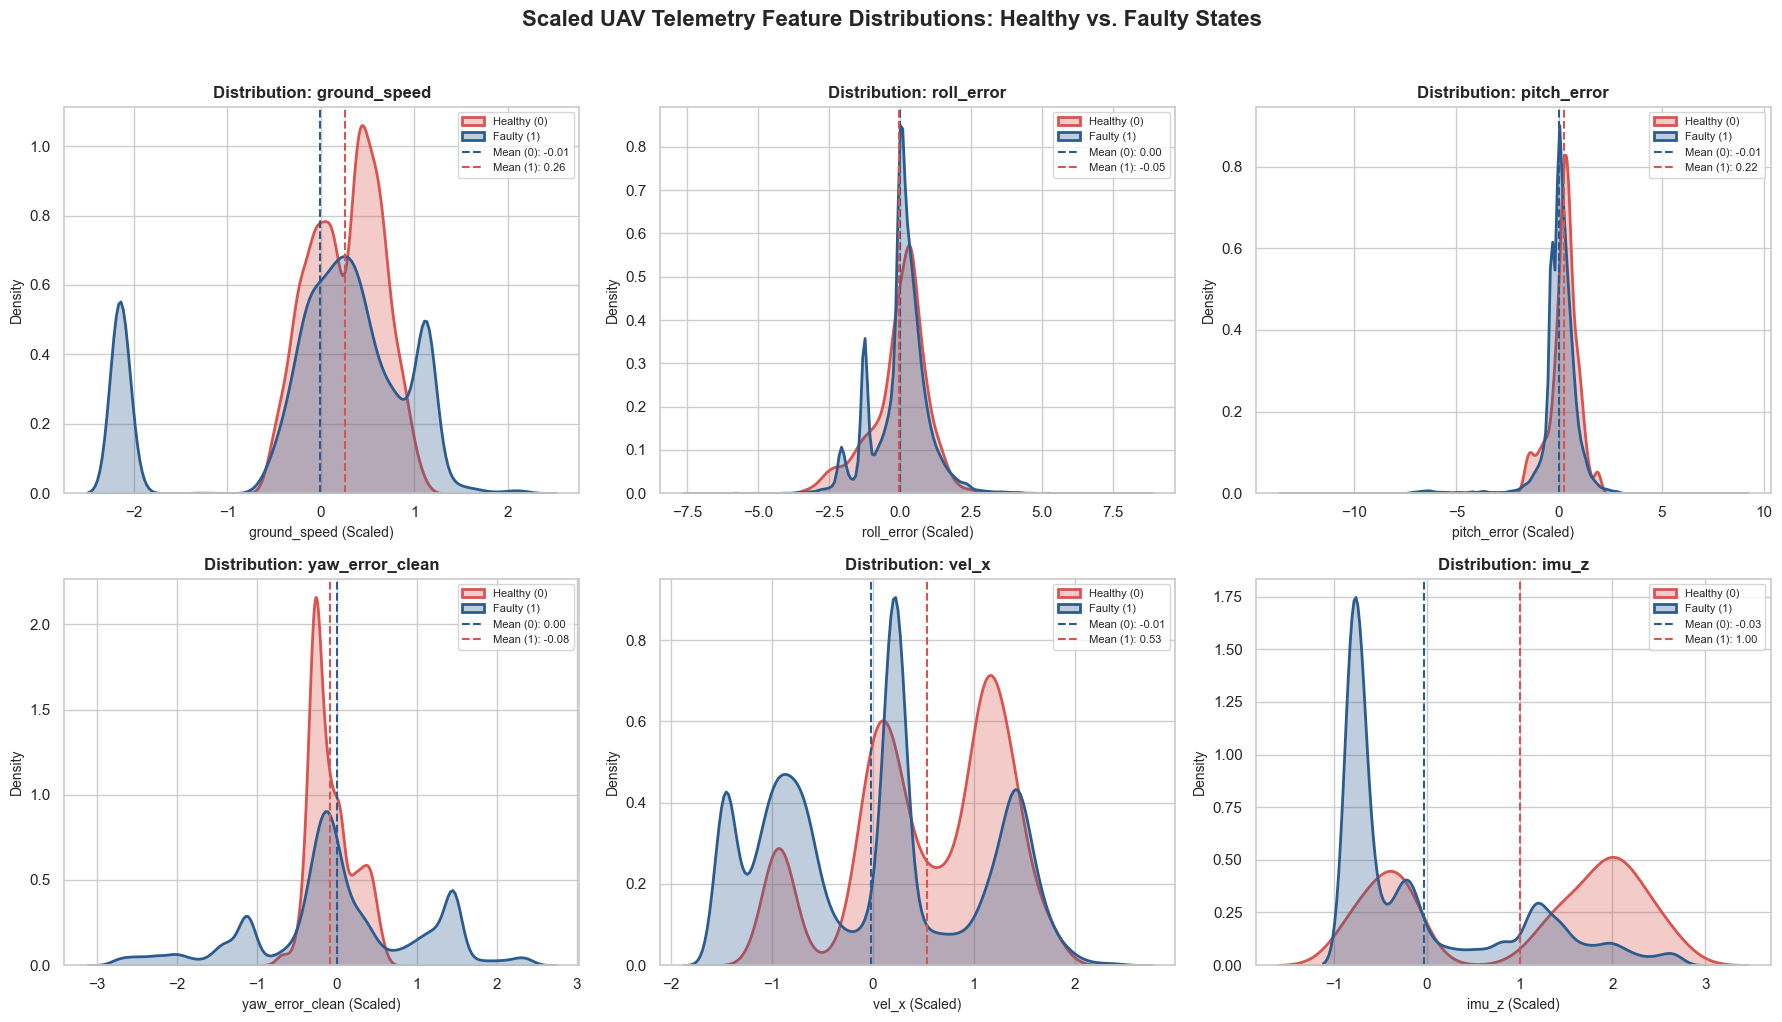

In [63]:
plot_df = df_train_scaled.copy()
plot_df['fault_within_5s'] = y_train.values  # Uses the matching train split predictive target

# Set visual style
sns.set_theme(style="whitegrid")

# Select core features to inspect distribution shifts
plot_features = [
    'ground_speed', 
    'roll_error', 
    'pitch_error', 
    'yaw_error_clean',
    'vel_x', 
    'imu_z'
]

# Create subplots grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    # Kernel Density Estimation (KDE) plot grouped by binary_fault
    sns.kdeplot(
        data=plot_df,
        x=feature,
        hue='fault_within_5s',
        common_norm=False,
        palette={0: '#2b5c8f', 1: '#d9534f'},
        fill=True,
        alpha=0.3,
        linewidth=2,
        ax=ax
    )
    
    # Calculate means per class for reference lines
    mean_0 = plot_df[plot_df['fault_within_5s'] == 0][feature].mean()
    mean_1 = plot_df[plot_df['fault_within_5s'] == 1][feature].mean()
    
    ax.axvline(mean_0, color='#2b5c8f', linestyle='--', linewidth=1.5, label=f'Healthy Mean: {mean_0:.2f}')
    ax.axvline(mean_1, color='#d9534f', linestyle='--', linewidth=1.5, label=f'Faulty Mean: {mean_1:.2f}')
    
    ax.set_title(f'Distribution: {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{feature} (Scaled)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(['Healthy (0)', 'Faulty (1)', f'Mean (0): {mean_0:.2f}', f'Mean (1): {mean_1:.2f}'], fontsize=8)

plt.suptitle('Scaled UAV Telemetry Feature Distributions: Healthy vs. Faulty States', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

StandardScaler transforms your raw telemetry values into standard deviation units ($z$-scores) so all features share a common scale, centered at a mean of $0$.
What Changed: yaw_error_clean (originally spanning $\pm 200$) and imu_z (spanning $\pm 1$) are now both scaled roughly between $-3$ and $+3$.Why It Matters: Distance- and gradient-based models (k-NN, SVM, Neural Networks) can now weight all 6 telemetry features equally without large-value features dominating the calculations.Data Shape: The underlying distribution shapes, peaks, and class separations between Healthy and Faulty states remain identical.

### Future Modeling Approaches

1. **Baseline – XGBoost**
   Establish a simple benchmark for predicting fault-related behavior using sensor and control features.

2. **Anomaly Detection**
   Learn normal UAV behavior and detect abnormal patterns that may appear before `fault_onset`.

3. **Liquid Neural Network (LNN)**
   Use time-series sequences to learn temporal UAV behavior and predict faults before they occur.

**Goal:** Compare the three approaches to determine whether modeling temporal behavior improves early fault prediction.


In [64]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated scale_pos_weight: {pos_weight:.2f}")


model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)


model.fit(
    df_train_scaled, y_train,
    eval_set=[(df_val_scaled, y_val)],
    verbose=50
)


val_probs = model.predict_proba(df_val_scaled)[:, 1]

val_preds = (val_probs >= 0.30).astype(int)

precision, recall, _ = precision_recall_curve(y_val, val_probs)
pr_auc_score = auc(recall, precision)

print(f"\n---> Validation PR-AUC: {pr_auc_score:.4f}\n")
print(classification_report(y_val, val_preds, target_names=['No fault in 5s (0)', 'Fault within 5s (1)']))


Calculated scale_pos_weight: 36.64
[0]	validation_0-aucpr:0.04511
[50]	validation_0-aucpr:0.06816
[75]	validation_0-aucpr:0.05328

---> Validation PR-AUC: 0.1004

                     precision    recall  f1-score   support

 No fault in 5s (0)       0.97      0.77      0.86     23231
Fault within 5s (1)       0.04      0.29      0.06       659

           accuracy                           0.76     23890
          macro avg       0.50      0.53      0.46     23890
       weighted avg       0.95      0.76      0.84     23890



In [65]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_2 = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

model_2.fit(
    df_train_scaled, y_train,
    eval_set=[(df_val_scaled, y_val)],
    verbose=100
)


val_probs_raw = model_2.predict_proba(df_val_scaled)[:, 1]

val_df = pd.DataFrame({
    'flight_id': flight_id_val.values,
    'raw_probs': val_probs_raw
})

# 10-frame rolling window mean per flight
val_probs_smooth = val_df.groupby('flight_id')['raw_probs'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
).values

# Threshold Search targeting F2-Score (Recall-focused, balanced precision)
best_thresh = 0.5
best_f2 = 0.0

for t in np.linspace(0.10, 0.90, 81):
    preds = (val_probs_smooth >= t).astype(int)
    score = fbeta_score(y_val, preds, beta=2.0, zero_division=0)
    if score > best_f2:
        best_f2 = score
        best_thresh = t

#  Final Evaluation
final_preds = (val_probs_smooth >= best_thresh).astype(int)
p, r, _ = precision_recall_curve(y_val, val_probs_smooth)

print(f"\n---> Optimal Threshold: {best_thresh:.2f}")
print(f"---> Smoothed Validation PR-AUC: {auc(r, p):.4f}")
print(f"---> Best F2-Score: {best_f2:.4f}\n")
print(classification_report(y_val, final_preds, target_names=['No fault in 5s (0)', 'Fault within 5s (1)']))


[0]	validation_0-aucpr:0.04511
[75]	validation_0-aucpr:0.05328

---> Optimal Threshold: 0.79
---> Smoothed Validation PR-AUC: 0.1128
---> Best F2-Score: 0.2146

                     precision    recall  f1-score   support

 No fault in 5s (0)       0.98      0.97      0.98     23231
Fault within 5s (1)       0.20      0.22      0.21       659

           accuracy                           0.95     23890
          macro avg       0.59      0.60      0.59     23890
       weighted avg       0.96      0.95      0.95     23890



## Leave-One-Fault-Flight-Out Cross-Validation

We only have ~10 faulty flights (12 episodes) in the training data, and a single
random train/val split leaves validation with just 3 episodes — far too few to
reliably tune a threshold or trust a single evaluation.

Instead: hold out **one faulty flight at a time**, train on everything else,
evaluate on the held-out flight, and repeat for all faulty flights. This gives
10 independent trials instead of 1, so we can see how *stable* the model's
performance actually is — and pick a threshold that generalizes across folds
rather than one fit to 3 lucky/unlucky episodes.


In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import fbeta_score, precision_recall_curve, auc

THRESH_GRID = np.linspace(0.10, 0.90, 33)

faulty_flights_cv = sorted(intervals_df['flight_id'].unique())
all_flights_pool = df_pred['flight_id'].unique()

fold_results = []
threshold_f2_matrix = []

for held_out_flight in faulty_flights_cv:
    train_flights = [f for f in all_flights_pool if f != held_out_flight]

    train_fold = df_pred[df_pred['flight_id'].isin(train_flights)]
    val_fold = df_pred[df_pred['flight_id'] == held_out_flight]

    X_train_fold = train_fold[features]
    y_train_fold = train_fold['fault_within_5s']
    X_val_fold = val_fold[features]
    y_val_fold = val_fold['fault_within_5s']

    if y_val_fold.sum() == 0:
        continue  # safety check, shouldn't happen for flights in intervals_df

    fold_scaler = StandardScaler()
    X_train_fold_scaled = fold_scaler.fit_transform(X_train_fold)
    X_val_fold_scaled = fold_scaler.transform(X_val_fold)

    pos_w = (y_train_fold == 0).sum() / max((y_train_fold == 1).sum(), 1)

    fold_model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=pos_w,
        eval_metric='aucpr',
        random_state=42,
        n_jobs=-1
    )
    fold_model.fit(X_train_fold_scaled, y_train_fold)

    val_probs_raw = fold_model.predict_proba(X_val_fold_scaled)[:, 1]
    val_probs_smooth = pd.Series(val_probs_raw).rolling(window=10, min_periods=1).mean().values

    precision_c, recall_c, _ = precision_recall_curve(y_val_fold, val_probs_smooth)
    pr_auc_fold = auc(recall_c, precision_c)

    f2_scores = [
        fbeta_score(y_val_fold, (val_probs_smooth >= t).astype(int), beta=2.0, zero_division=0)
        for t in THRESH_GRID
    ]
    threshold_f2_matrix.append(f2_scores)

    best_t_idx = int(np.argmax(f2_scores))
    fold_results.append({
        'held_out_flight': held_out_flight,
        'n_val_frames': len(y_val_fold),
        'n_val_positive': int(y_val_fold.sum()),
        'pr_auc': pr_auc_fold,
        'best_thresh_this_fold': THRESH_GRID[best_t_idx],
        'best_f2_this_fold': f2_scores[best_t_idx],
    })

cv_results_df = pd.DataFrame(fold_results)
print(cv_results_df.to_string(index=False))

print(f"\nMean PR-AUC across folds:        {cv_results_df['pr_auc'].mean():.4f} (std: {cv_results_df['pr_auc'].std():.4f})")
print(f"Mean best F2 across folds:        {cv_results_df['best_f2_this_fold'].mean():.4f} (std: {cv_results_df['best_f2_this_fold'].std():.4f})")
print(f"Std of best-fold thresholds:      {cv_results_df['best_thresh_this_fold'].std():.4f}")
print("  (high std here = the 'ideal' threshold varies wildly fold to fold = unstable)")

# Average F2 per threshold ACROSS folds -> most generalizable single threshold
threshold_f2_matrix = np.array(threshold_f2_matrix)
avg_f2_per_thresh = threshold_f2_matrix.mean(axis=0)
best_stable_thresh = THRESH_GRID[np.argmax(avg_f2_per_thresh)]
print(f"\nMost stable threshold across all folds: {best_stable_thresh:.2f} "
      f"(avg F2 = {avg_f2_per_thresh.max():.4f})")


 held_out_flight  n_val_frames  n_val_positive   pr_auc  best_thresh_this_fold  best_f2_this_fold
               0          5860             189 0.080531                  0.150           0.230769
               5          6312             194 0.097842                  0.100           0.066964
              14          3281             187 0.395855                  0.100           0.636008
              15          6269              94 0.179819                  0.325           0.545455
              16          2501              94 0.274271                  0.150           0.453668
              17          3052              97 0.404683                  0.100           0.374449
              19          4505             195 0.395466                  0.100           0.670103
              20          5257             187 0.126108                  0.100           0.000000
              22          4655             197 0.183161                  0.100           0.468870
              27    

## Final Model — Retrain on All Available Training Data

The cross-validation above showed the val-only threshold (0.79) was badly
miscalibrated — it was fit to just 3 fault episodes. The threshold that
generalizes best across all 10 held-out folds is **~0.28**.

Now that we've validated the approach, we retrain one final model on **all**
available training data (train + val combined — no need to hold out a
validation slice anymore, since threshold selection is already done via CV),
and evaluate it **once** on the true test set using the CV-selected threshold.


In [67]:
X_full_raw = df_pred[features].copy()
y_full = df_pred['fault_within_5s'].copy()
flight_id_full = df_pred['flight_id'].copy()

final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X_full_raw)

X_test_final_raw = df_test_pred[features].copy()
X_test_final_scaled = final_scaler.transform(X_test_final_raw)

pos_weight_full = (y_full == 0).sum() / (y_full == 1).sum()

final_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.5,
    max_depth=10,
    scale_pos_weight=pos_weight_full,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_full_scaled, y_full)

FINAL_THRESH = best_stable_thresh  # from the cross-validation cell above

print(f"Final model trained on {len(y_full)} frames ({int(y_full.sum())} positive) "
      f"across {df_pred['flight_id'].nunique()} flights.")
print(f"Using CV-selected threshold: {FINAL_THRESH:.2f}")


Final model trained on 113215 frames (3032 positive) across 30 flights.
Using CV-selected threshold: 0.10


### Final, single evaluation on the held-out TEST set

This is the one true, non-leaky check — the threshold and model were chosen
using only training-side cross-validation, and this is the first and only
time they touch `df_test`.


In [68]:
test_probs_final_raw = final_model.predict_proba(X_test_final_scaled)[:, 1]

test_df_final = pd.DataFrame({
    'flight_id': flight_id_test.values,
    'raw_probs': test_probs_final_raw
})

test_probs_final_smooth = test_df_final.groupby('flight_id')['raw_probs'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
).values

test_preds_final = (test_probs_final_smooth >= FINAL_THRESH).astype(int)

p_f, r_f, _ = precision_recall_curve(y_test, test_probs_final_smooth)
pr_auc_final = auc(r_f, p_f)
f2_final = fbeta_score(y_test, test_preds_final, beta=2.0, zero_division=0)

print(f"=== FINAL MODEL (trained on all train+val, threshold={FINAL_THRESH:.2f}) on TEST set ===")
print(f"Test PR-AUC: {pr_auc_final:.4f}")
print(f"Test F2-score: {f2_final:.4f}  (same metric used to pick the threshold via CV)\n")
print(classification_report(y_test, test_preds_final, target_names=['No fault in 5s (0)', 'Fault within 5s (1)']))


=== FINAL MODEL (trained on all train+val, threshold=0.10) on TEST set ===
Test PR-AUC: 0.1550
Test F2-score: 0.2994  (same metric used to pick the threshold via CV)

                     precision    recall  f1-score   support

 No fault in 5s (0)       0.99      0.98      0.99     40665
Fault within 5s (1)       0.20      0.34      0.25       470

           accuracy                           0.98     41135
          macro avg       0.59      0.66      0.62     41135
       weighted avg       0.98      0.98      0.98     41135



In [69]:
# Retrain the baseline model too, on the SAME final_scaler + full data, so it
# stays consistent with what gets saved and loaded together in the app
# (mixing a model with a scaler it wasn't trained on would silently corrupt predictions).
final_baseline_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=pos_weight_full,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
final_baseline_model.fit(X_full_scaled, y_full)
print("Baseline model retrained on final_scaler-transformed full data for consistency.")


Baseline model retrained on final_scaler-transformed full data for consistency.


In [70]:
import joblib

# Save the FINAL models (trained on all train+val, using final_scaler, with the
# CV-validated threshold) — this is what the Streamlit app will load.
joblib.dump(final_model, "xgboost_f2_v3.pkl")
joblib.dump(final_baseline_model, "xgboost_baseline_v3.pkl")
joblib.dump(final_scaler, "scaler_v3.pkl")
joblib.dump(FINAL_THRESH, "best_thresh_v3.pkl")
joblib.dump(features, "features_v3.pkl")
joblib.dump(HORIZON_SEC, "horizon_sec_v3.pkl")

print("Saved: xgboost_baseline.pkl (FINAL), xgboost_f2.pkl (FINAL), scaler.pkl (FINAL), "
      "features.pkl, best_thresh.pkl (FINAL), horizon_sec.pkl")


Saved: xgboost_baseline.pkl (FINAL), xgboost_f2.pkl (FINAL), scaler.pkl (FINAL), features.pkl, best_thresh.pkl (FINAL), horizon_sec.pkl


In [71]:
# ---- Final evaluation on the held-out TEST set ----
# Predictive target: will a fault onset occur within the next 5 seconds?
# Uses the scaler fitted on train only, and the two models already trained/saved.

test_probs_model1 = model.predict_proba(df_test_scaled)[:, 1]
test_preds_model1 = (test_probs_model1 >= 0.30).astype(int)

precision_t, recall_t, _ = precision_recall_curve(y_test, test_probs_model1)
pr_auc_test = auc(recall_t, precision_t)

print("=== Model 1 (xgboost_baseline) on TEST set ===")
print(f"Test PR-AUC: {pr_auc_test:.4f}\n")
print(classification_report(y_test, test_preds_model1, target_names=['No fault in 5s (0)', 'Fault within 5s (1)']))

# Model 2 uses the same rolling-smoothing + best_thresh found on validation
test_probs_model2_raw = model_2.predict_proba(df_test_scaled)[:, 1]

test_df = pd.DataFrame({
    'flight_id': flight_id_test.values,
    'raw_probs': test_probs_model2_raw
})

test_probs_smooth = test_df.groupby('flight_id')['raw_probs'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
).values

test_preds_model2 = (test_probs_smooth >= best_thresh).astype(int)
p_t, r_t, _ = precision_recall_curve(y_test, test_probs_smooth)

print("\n=== Model 2 (xgboost_f2, smoothed) on TEST set ===")
print(f"Using threshold from validation: {best_thresh:.2f}")
print(f"Smoothed Test PR-AUC: {auc(r_t, p_t):.4f}\n")
print(classification_report(y_test, test_preds_model2, target_names=['No fault in 5s (0)', 'Fault within 5s (1)']))


=== Model 1 (xgboost_baseline) on TEST set ===
Test PR-AUC: 0.0387

                     precision    recall  f1-score   support

 No fault in 5s (0)       0.99      0.92      0.95     40665
Fault within 5s (1)       0.03      0.18      0.05       470

           accuracy                           0.91     41135
          macro avg       0.51      0.55      0.50     41135
       weighted avg       0.98      0.91      0.94     41135


=== Model 2 (xgboost_f2, smoothed) on TEST set ===
Using threshold from validation: 0.79
Smoothed Test PR-AUC: 0.0366

                     precision    recall  f1-score   support

 No fault in 5s (0)       0.99      0.98      0.99     40665
Fault within 5s (1)       0.02      0.03      0.03       470

           accuracy                           0.97     41135
          macro avg       0.51      0.51      0.51     41135
       weighted avg       0.98      0.97      0.98     41135

